# Bank Marketing: modelo reproducible y preparación para producción

Este notebook desarrolla paso a paso un clasificador que estima si un cliente aceptará un depósito a plazo (`y = yes/no`) usando `bank.csv`.

> **Restricción crítica:** `duration` se excluye de todo entrenamiento e inferencia. Solo se conoce después de la llamada y usarla produciría *data leakage* en producción.

El flujo compara al menos dos modelos, selecciona hiperparámetros con validación cruzada, ajusta el umbral en un conjunto de validación separado, evalúa una sola vez en test, reentrena el modelo ganador con todos los datos y serializa la tubería completa para FastAPI.

## 1. Objetivo, decisiones y criterios

- **Unidad de análisis:** un contacto de campaña por fila.
- **Objetivo:** detectar la clase minoritaria `yes` sin depender de exactitud simple.
- **Métricas principales:** F1 de `yes` y balanced accuracy; también se reportan ROC-AUC, precision y recall.
- **Partición:** 60% entrenamiento, 20% validación y 20% test, siempre estratificada.
- **Selección:** búsqueda pequeña y reproducible con 5-fold CV sobre entrenamiento.
- **Umbral:** elegido en validación para maximizar F1; el test queda intacto hasta la evaluación final.
- **Modelos candidatos:** regresión logística y Random Forest.
- **Nivel del sistema:** nivel 1, predicción. No ejecuta acciones sobre clientes.

In [1]:
from pathlib import Path
import json
import platform
from datetime import datetime, timezone

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42
BASE_DIR = Path.cwd()
DATA_PATH = BASE_DIR / "bank.csv"
MODEL_PATH = BASE_DIR / "model.joblib"
METADATA_PATH = BASE_DIR / "model_metadata.json"

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.figsize": (9, 5), "axes.titleweight": "bold"})

print({
    "python": platform.python_version(),
    "pandas": pd.__version__,
    "scikit_learn": sklearn.__version__,
    "dataset": str(DATA_PATH.resolve()),
})

{'python': '3.13.1', 'pandas': '2.3.0', 'scikit_learn': '1.8.0', 'dataset': 'C:\\Users\\jeffr\\GitHub\\2026-II\\PlanIA\\S6\\bank.csv'}


## 2. Carga y controles de calidad

El archivo UCI usa `;` como separador. Se comprueban esquema, duplicados, valores faltantes y clases antes de modelar.

In [2]:
data = pd.read_csv(DATA_PATH, sep=";")

expected_columns = {
    "age", "job", "marital", "education", "default", "balance",
    "housing", "loan", "contact", "day", "month", "duration",
    "campaign", "pdays", "previous", "poutcome", "y",
}
assert set(data.columns) == expected_columns, "El esquema de bank.csv cambió."
assert set(data["y"].unique()) == {"yes", "no"}, "La variable objetivo no es binaria."

quality_summary = pd.Series({
    "filas": len(data),
    "columnas": data.shape[1],
    "duplicados_exactos": int(data.duplicated().sum()),
    "valores_nulos": int(data.isna().sum().sum()),
    "tasa_yes": float((data["y"] == "yes").mean()),
})
display(quality_summary.to_frame("valor"))
display(data.head())

,valor
filas,4521.00000
columnas,17.00000
duplicados_exactos,0.00000
valores_nulos,0.00000
tasa_yes,0.11524


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


### 2.1 Balance de clases

La clase positiva es minoritaria; por eso balanced accuracy y F1 son más informativas que accuracy.

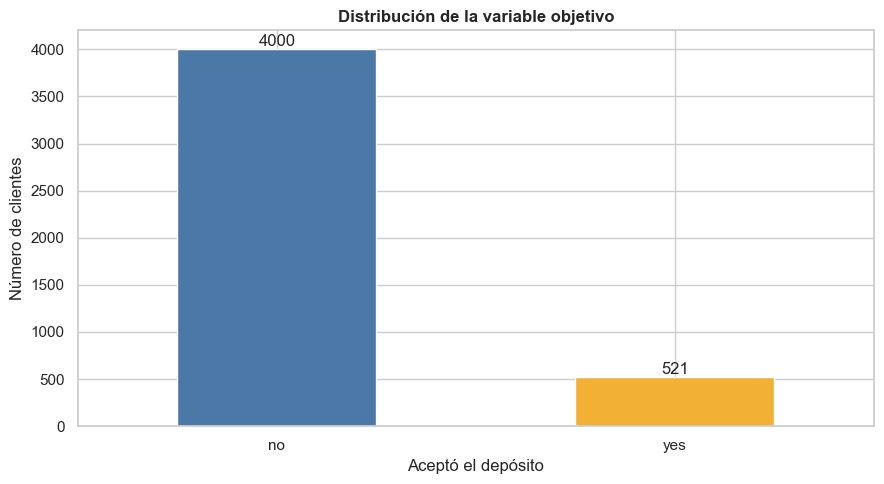

,conteo,porcentaje
y,,
no,4000,0.88476
yes,521,0.11524


In [3]:
target_counts = data["y"].value_counts().reindex(["no", "yes"])
ax = target_counts.plot(kind="bar", color=["#4C78A8", "#F2B134"], rot=0)
ax.set_title("Distribución de la variable objetivo")
ax.set_xlabel("Aceptó el depósito")
ax.set_ylabel("Número de clientes")
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
plt.show()

display(pd.DataFrame({"conteo": target_counts, "porcentaje": target_counts / len(data)}))

### 2.2 Revisión de leakage

`duration` tiene una relación fuerte con el resultado porque mide cuánto duró la llamada. Sin embargo, al decidir a quién contactar aún no existe. Se muestra solo para documentar el riesgo y se elimina inmediatamente del conjunto de predictores. También se evita cualquier variable derivada de `y`.

,count,mean,median
y,,,
no,4000,226.347500,167.0
yes,521,552.742802,442.0


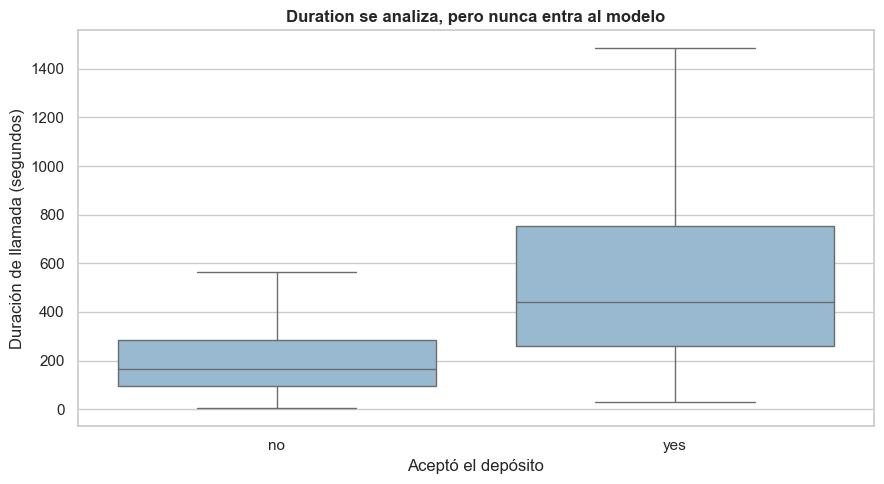

In [4]:
duration_summary = data.groupby("y")["duration"].agg(["count", "mean", "median"])
display(duration_summary)

ax = sns.boxplot(data=data, x="y", y="duration", order=["no", "yes"], color="#8FBBD9", showfliers=False)
ax.set_title("Duration se analiza, pero nunca entra al modelo")
ax.set_xlabel("Aceptó el depósito")
ax.set_ylabel("Duración de llamada (segundos)")
plt.tight_layout()
plt.show()

## 3. Variables y particiones

Se conservan todas las variables disponibles antes de la llamada salvo `duration`. Las categorías `unknown` se mantienen como valores observados; no se convierten automáticamente en nulos.

In [5]:
TARGET = "y"
LEAKAGE_COLUMNS = ["duration"]

X = data.drop(columns=[TARGET, *LEAKAGE_COLUMNS])
y = (data[TARGET] == "yes").astype(int)

numeric_features = X.select_dtypes(include="number").columns.tolist()
categorical_features = X.select_dtypes(exclude="number").columns.tolist()
feature_names = X.columns.tolist()

assert "duration" not in feature_names
print("Variables numéricas:", numeric_features)
print("Variables categóricas:", categorical_features)
print("Total de predictores:", len(feature_names))

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.40, stratify=y, random_state=RANDOM_STATE
)
X_validation, X_test, y_validation, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE
)

split_summary = pd.DataFrame({
    "filas": [len(X_train), len(X_validation), len(X_test)],
    "tasa_yes": [y_train.mean(), y_validation.mean(), y_test.mean()],
}, index=["train", "validation", "test"])
display(split_summary)

Variables numéricas: ['age', 'balance', 'day', 'campaign', 'pdays', 'previous']
Variables categóricas: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
Total de predictores: 15


,filas,tasa_yes
train,2712,0.115413
validation,904,0.115044
test,905,0.114917


## 4. Preprocesamiento reproducible

La tubería imputa numéricos, estandariza y aplica one-hot encoding con categorías desconocidas ignoradas. El preprocesamiento se ajusta dentro de cada fold para evitar leakage entre particiones.

In [6]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=2)),
])
preprocessor = ColumnTransformer([
    ("numeric", numeric_transformer, numeric_features),
    ("categorical", categorical_transformer, categorical_features),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {"f1": "f1", "balanced_accuracy": "balanced_accuracy", "roc_auc": "roc_auc"}

## 5. Modelo 1: regresión logística

Es una base interpretable y eficiente. `class_weight='balanced'` reduce el sesgo hacia la clase mayoritaria.

In [7]:
logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=3000, class_weight="balanced", random_state=RANDOM_STATE)),
])
logistic_search = GridSearchCV(
    logistic_pipeline,
    param_grid={"model__C": [0.1, 1.0, 10.0]},
    scoring=scoring,
    refit="f1",
    cv=cv,
    n_jobs=-1,
    return_train_score=False,
)
logistic_search.fit(X_train, y_train)
print("Mejores parámetros:", logistic_search.best_params_)

Mejores parámetros: {'model__C': 0.1}


## 6. Modelo 2: Random Forest

Captura relaciones no lineales e interacciones. El tamaño se mantiene acotado para que la API sea ligera.

In [8]:
forest_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])
forest_search = GridSearchCV(
    forest_pipeline,
    param_grid={
        "model__max_depth": [None, 10],
        "model__min_samples_leaf": [1, 5],
    },
    scoring=scoring,
    refit="f1",
    cv=cv,
    n_jobs=-1,
    return_train_score=False,
)
forest_search.fit(X_train, y_train)
print("Mejores parámetros:", forest_search.best_params_)

Mejores parámetros: {'model__max_depth': 10, 'model__min_samples_leaf': 5}


## 7. Comparación y selección

La decisión usa el F1 promedio de validación cruzada. Balanced accuracy y ROC-AUC se muestran como controles complementarios.

In [9]:
def best_cv_row(name, search):
    index = search.best_index_
    return {
        "modelo": name,
        "cv_f1_mean": search.cv_results_["mean_test_f1"][index],
        "cv_f1_std": search.cv_results_["std_test_f1"][index],
        "cv_balanced_accuracy": search.cv_results_["mean_test_balanced_accuracy"][index],
        "cv_roc_auc": search.cv_results_["mean_test_roc_auc"][index],
        "best_params": search.best_params_,
    }

comparison = pd.DataFrame([
    best_cv_row("logistic_regression", logistic_search),
    best_cv_row("random_forest", forest_search),
]).sort_values("cv_f1_mean", ascending=False).reset_index(drop=True)
display(comparison)

searches = {
    "logistic_regression": logistic_search,
    "random_forest": forest_search,
}
selected_model_name = comparison.loc[0, "modelo"]
selected_search = searches[selected_model_name]
selected_pipeline = selected_search.best_estimator_
print("Modelo seleccionado:", selected_model_name)

,modelo,cv_f1_mean,cv_f1_std,cv_balanced_accuracy,cv_roc_auc,best_params
0,random_forest,0.406225,0.025859,0.664202,0.747127,"{'model__max_depth': 10, 'model__min_samples_l..."
1,logistic_regression,0.331510,0.017685,0.669335,0.727745,{'model__C': 0.1}


Modelo seleccionado: random_forest


## 8. Ajuste del umbral en validación

El umbral 0.5 no siempre maximiza F1 con clases desbalanceadas. Se elige en validation y se congela antes de abrir test.

,valor
threshold,0.485318
validation_f1,0.355932
validation_precision,0.318182
validation_recall,0.403846


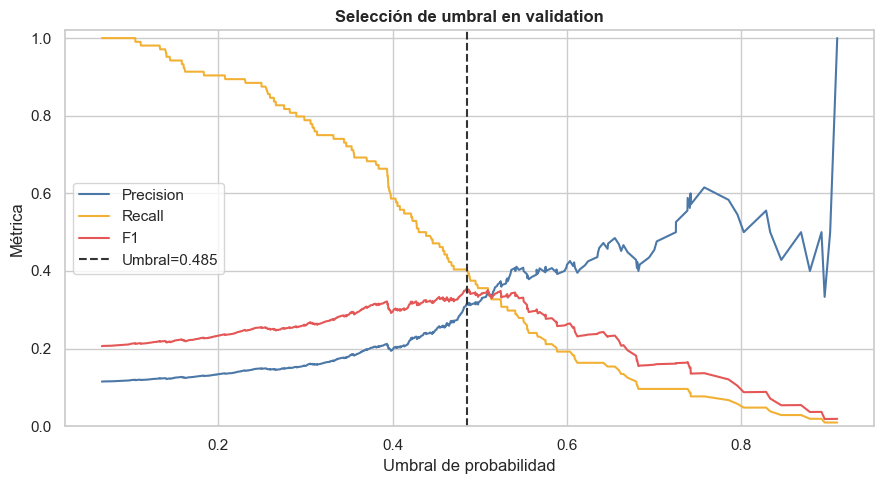

In [10]:
validation_probability = selected_pipeline.predict_proba(X_validation)[:, 1]
precision_curve, recall_curve, thresholds = precision_recall_curve(y_validation, validation_probability)
f1_curve = 2 * precision_curve[:-1] * recall_curve[:-1] / np.clip(
    precision_curve[:-1] + recall_curve[:-1], 1e-12, None
)
best_threshold_index = int(np.nanargmax(f1_curve))
selected_threshold = float(thresholds[best_threshold_index])

threshold_result = pd.Series({
    "threshold": selected_threshold,
    "validation_f1": float(f1_curve[best_threshold_index]),
    "validation_precision": float(precision_curve[best_threshold_index]),
    "validation_recall": float(recall_curve[best_threshold_index]),
})
display(threshold_result.to_frame("valor"))

fig, ax = plt.subplots()
ax.plot(thresholds, precision_curve[:-1], label="Precision", color="#4C78A8")
ax.plot(thresholds, recall_curve[:-1], label="Recall", color="#F2B134")
ax.plot(thresholds, f1_curve, label="F1", color="#E45756")
ax.axvline(selected_threshold, color="#333333", linestyle="--", label=f"Umbral={selected_threshold:.3f}")
ax.set_title("Selección de umbral en validation")
ax.set_xlabel("Umbral de probabilidad")
ax.set_ylabel("Métrica")
ax.set_ylim(0, 1.02)
ax.legend()
plt.tight_layout()
plt.show()

## 9. Evaluación final en test

El conjunto test no se usó para escoger modelo, hiperparámetros ni umbral. Estas son las métricas de referencia para el modelo final.

,test
f1,0.369231
balanced_accuracy,0.663354
roc_auc,0.737083
precision,0.307692
recall,0.461538


              precision    recall  f1-score   support

          no       0.93      0.87      0.89       801
         yes       0.31      0.46      0.37       104

    accuracy                           0.82       905
   macro avg       0.62      0.66      0.63       905
weighted avg       0.85      0.82      0.83       905



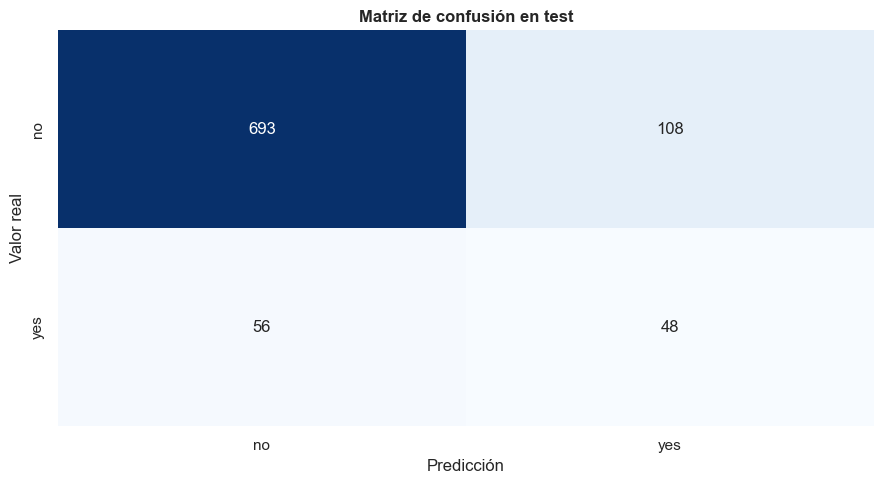

In [11]:
test_probability = selected_pipeline.predict_proba(X_test)[:, 1]
test_prediction = (test_probability >= selected_threshold).astype(int)

test_metrics = {
    "f1": float(f1_score(y_test, test_prediction)),
    "balanced_accuracy": float(balanced_accuracy_score(y_test, test_prediction)),
    "roc_auc": float(roc_auc_score(y_test, test_probability)),
    "precision": float(precision_score(y_test, test_prediction, zero_division=0)),
    "recall": float(recall_score(y_test, test_prediction, zero_division=0)),
}
display(pd.Series(test_metrics).to_frame("test"))
print(classification_report(y_test, test_prediction, target_names=["no", "yes"], zero_division=0))

matrix = confusion_matrix(y_test, test_prediction)
ax = sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", cbar=False,
                 xticklabels=["no", "yes"], yticklabels=["no", "yes"])
ax.set_title("Matriz de confusión en test")
ax.set_xlabel("Predicción")
ax.set_ylabel("Valor real")
plt.tight_layout()
plt.show()

## 10. Reentrenamiento con todos los datos y serialización

Se conserva la configuración ganadora y se reentrena la tubería con las 4,521 filas. Las métricas anteriores siguen siendo la referencia honesta; no se calculan métricas sobre el mismo conjunto usado para el ajuste final.

In [12]:
final_pipeline = selected_search.best_estimator_.set_params(**selected_search.best_params_)
final_pipeline.fit(X, y)

model_bundle = {
    "pipeline": final_pipeline,
    "threshold": selected_threshold,
    "feature_names": feature_names,
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "target_labels": {0: "no", 1: "yes"},
    "excluded_features": LEAKAGE_COLUMNS,
}
joblib.dump(model_bundle, MODEL_PATH)

metadata = {
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "dataset": "bank.csv",
    "rows": len(data),
    "selected_model": selected_model_name,
    "best_params": selected_search.best_params_,
    "threshold": selected_threshold,
    "test_metrics": test_metrics,
    "cv_comparison": json.loads(comparison.to_json(orient="records")),
    "feature_names": feature_names,
    "excluded_features": LEAKAGE_COLUMNS,
    "random_state": RANDOM_STATE,
    "sklearn_version": sklearn.__version__,
    "system_level": "1 - Predicción",
}
METADATA_PATH.write_text(json.dumps(metadata, indent=2, ensure_ascii=False), encoding="utf-8")

print(f"Modelo guardado en: {MODEL_PATH.resolve()} ({MODEL_PATH.stat().st_size / 1024:.1f} KiB)")
print(f"Metadatos guardados en: {METADATA_PATH.resolve()}")

Modelo guardado en: C:\Users\jeffr\GitHub\2026-II\PlanIA\S6\model.joblib (5504.5 KiB)
Metadatos guardados en: C:\Users\jeffr\GitHub\2026-II\PlanIA\S6\model_metadata.json


## 11. Prueba de la función de inferencia

La misma función que consumirá FastAPI valida esquema, bloquea `duration` y devuelve predicción, probabilidades, confianza y umbral.

In [13]:
from inference import InputValidationError, load_model_bundle, predict

load_model_bundle.cache_clear()
example = X.iloc[0].to_dict()
prediction_example = predict(example)
display(prediction_example)

try:
    predict({**example, "duration": 99})
except InputValidationError as exc:
    print("Validación de leakage correcta:", exc)

{'prediction': 'yes',
 'probabilities': {'no': 0.367195, 'yes': 0.632805},
 'confidence': 0.632805,
 'threshold': 0.485318}

Validación de leakage correcta: Campos prohibidos por leakage o por ser el objetivo: duration


## 12. Conclusiones, riesgos y siguiente paso

- La selección se basa en F1 con validación cruzada y un umbral ajustado fuera de test.
- `duration` no aparece en `feature_names`, el artefacto ni el contrato de FastAPI.
- El modelo entrega una probabilidad, pero no es causal ni garantiza que contactar a un cliente produzca aceptación.
- Puede existir sesgo por representatividad histórica, cambios de campaña y categorías desconocidas.
- El sistema es **nivel 1 - Predicción**: informa a una persona; no recomienda automáticamente ni ejecuta contactos.
- Para producción real se deben monitorear distribución de variables, tasa de positivos, calibración, errores por segmento y desempeño con etiquetas posteriores.

El despliegue se realiza con el `Dockerfile`, `app.py`, `inference.py` y `deploy.ps1` incluidos en esta carpeta.